# 00 — EDA: IEEE-CIS Fraud Detection

Exploratory analysis of the **labeled** training data only (`train_transaction` LEFT JOIN `train_identity`). The unlabeled test files are never touched here (invariant 2).

Questions: How imbalanced is fraud? Where is the missingness, and is it structured? Does identity presence carry signal? How does fraud move over time? A written summary of findings is at the bottom.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fraud_detection_mlops import config
from fraud_detection_mlops.data import load_training_data, validate_training_data
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 60); plt.rcParams['figure.figsize'] = (7, 4)

In [2]:
df = load_training_data()  # train_transaction LEFT JOIN train_identity (+ has_identity)
summary = validate_training_data(df)
print(f'rows={len(df):,}   cols={df.shape[1]}')
summary

rows=590,540   cols=435


{'n_rows': 590540,
 'n_cols': 435,
 'fraud_rate': 0.03499000914417313,
 'transactiondt_min': 86400,
 'transactiondt_max': 15811131,
 'identity_match_rate': 0.2442391709283029}

## 1. Class imbalance

fraud rate = 3.4990%   (20,663 fraud / 590,540 total)


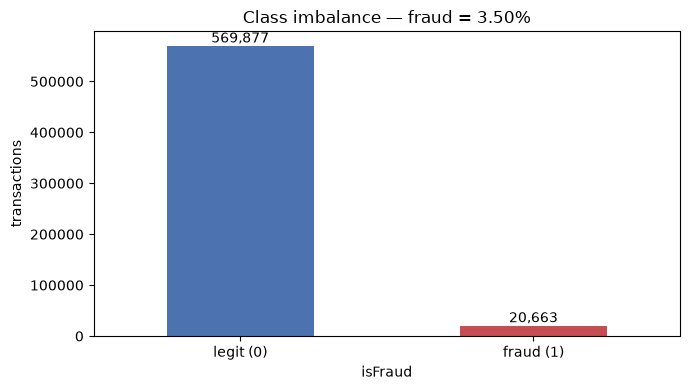

In [3]:
fraud_rate = df['isFraud'].mean()
counts = df['isFraud'].value_counts().sort_index()
print(f'fraud rate = {fraud_rate:.4%}   ({int(counts.get(1,0)):,} fraud / {len(df):,} total)')
ax = counts.plot(kind='bar', color=['#4c72b0', '#c44e52'])
ax.set_xticklabels(['legit (0)', 'fraud (1)'], rotation=0)
ax.set_title(f'Class imbalance — fraud = {fraud_rate:.2%}'); ax.set_ylabel('transactions')
for i, v in enumerate(counts): ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout(); plt.savefig(config.FIGURES_DIR/'class_imbalance.png', dpi=110); plt.show()

**~3.5% fraud** (≈1:27 legit:fraud). This is why accuracy is banned as a headline (invariant 3): always-predict-legit already scores 96.5% accuracy and catches zero fraud. We measure PR-AUC and precision@k instead.

## 2. Missingness by column block

C (C1-14)      0.0%
card (1-6)     0.5%
V (V1-339)    43.0%
addr/dist     43.9%
email         46.4%
M (M1-9)      49.9%
D (D1-15)     58.2%
id_ (1-38)    84.8%


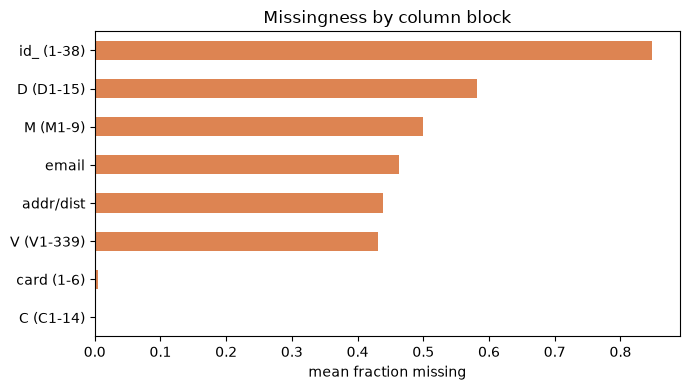

In [4]:
blocks = {
    'C (C1-14)':  [f'C{i}' for i in range(1,15)],
    'D (D1-15)':  [f'D{i}' for i in range(1,16)],
    'M (M1-9)':   [f'M{i}' for i in range(1,10)],
    'V (V1-339)': [f'V{i}' for i in range(1,340)],
    'id_ (1-38)': [f'id_{i:02d}' for i in range(1,39)],
    'card (1-6)': [f'card{i}' for i in range(1,7)],
    'addr/dist':  ['addr1','addr2','dist1','dist2'],
    'email':      ['P_emaildomain','R_emaildomain'],
}
miss = {n: df[[c for c in cs if c in df.columns]].isna().mean().mean() for n, cs in blocks.items()}
ms = pd.Series(miss).sort_values()
print(ms.apply(lambda x: f'{x:.1%}').to_string())
ax = ms.plot(kind='barh', color='#dd8452')
ax.set_xlabel('mean fraction missing'); ax.set_title('Missingness by column block')
plt.tight_layout(); plt.savefig(config.FIGURES_DIR/'missingness_by_block.png', dpi=110); plt.show()

Missingness is **heavy and structured**, not random: the `id_*` block is ~85% empty (it only exists for the ~24% of rows with an identity match), while `D` (~58%), `M` (~50%), `email` (~46%) and `V` (~43%) are also sparse. `C` and `card` are essentially complete. *Structured* missingness means the fact that a value is missing is itself information — we handle NaNs deliberately rather than blanket-dropping.

## 3. Identity presence as a signal

identity match rate = 24.42%
fraud | has_identity = 7.85%   fraud | none = 2.09%   ratio = 3.7x


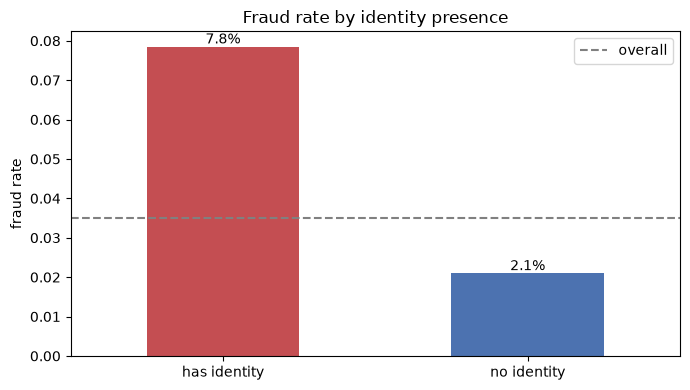

In [5]:
hi = df['has_identity'] == 1
fr_with, fr_without = df.loc[hi,'isFraud'].mean(), df.loc[~hi,'isFraud'].mean()
print(f'identity match rate = {hi.mean():.2%}')
print(f'fraud | has_identity = {fr_with:.2%}   fraud | none = {fr_without:.2%}   ratio = {fr_with/fr_without:.1f}x')
ax = pd.Series({'has identity': fr_with, 'no identity': fr_without}).plot(kind='bar', color=['#c44e52','#4c72b0'])
ax.set_xticklabels(['has identity','no identity'], rotation=0)
ax.axhline(df['isFraud'].mean(), ls='--', color='grey', label='overall')
ax.set_ylabel('fraud rate'); ax.set_title('Fraud rate by identity presence'); ax.legend()
for i, v in enumerate([fr_with, fr_without]): ax.text(i, v, f'{v:.1%}', ha='center', va='bottom')
plt.tight_layout(); plt.savefig(config.FIGURES_DIR/'fraud_by_identity.png', dpi=110); plt.show()

Only ~24% of rows have identity data, but those rows are **~3.7× more likely to be fraud** (7.8% vs 2.1%). Whether identity info exists *at all* is a stronger signal than most individual columns — which is exactly why we engineer the `has_identity` flag before the LEFT JOIN buries it in NaNs.

## 4. Device breakdown

             count      mean
DeviceType                  
(none)      449730  0.021017
desktop      85165  0.065215
mobile       55645  0.101662


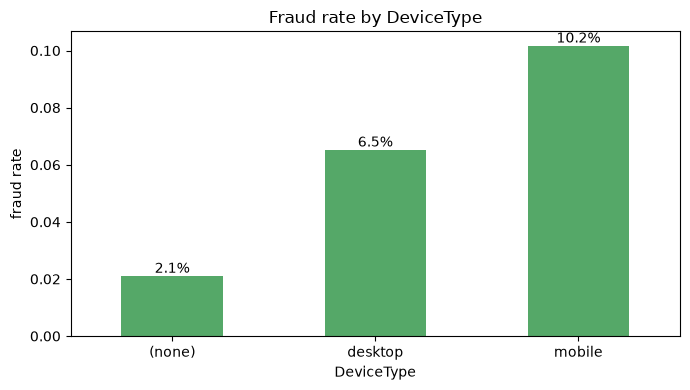


Top DeviceInfo by volume:
                        count      mean
DeviceInfo                             
(none)                 471874  0.025549
Windows                 47722  0.065400
iOS Device              19782  0.062683
MacOS                   12573  0.022111
Trident/7.0              7440  0.012903
rv:11.0                  1901  0.039979
rv:57.0                   962  0.107069
SM-J700M Build/MMB29K     549  0.109290
SM-G610M Build/MMB29K     461  0.080260
SM-G531H Build/LMY48B     410  0.080488


In [6]:
dev = df.assign(DeviceType=df['DeviceType'].fillna('(none)')).groupby('DeviceType')['isFraud'].agg(['count','mean'])
print(dev.to_string())
ax = dev['mean'].plot(kind='bar', color='#55a868')
ax.set_ylabel('fraud rate'); ax.set_title('Fraud rate by DeviceType'); plt.xticks(rotation=0)
for i, v in enumerate(dev['mean']): ax.text(i, v, f'{v:.1%}', ha='center', va='bottom')
plt.tight_layout(); plt.savefig(config.FIGURES_DIR/'fraud_by_devicetype.png', dpi=110); plt.show()
top_dev = (df.groupby(df['DeviceInfo'].fillna('(none)'))['isFraud'].agg(['count','mean'])
            .sort_values('count', ascending=False).head(10))
print('\nTop DeviceInfo by volume:'); print(top_dev.to_string())

Among rows that *have* a device, **mobile (10.2% fraud) is riskier than desktop (6.5%)**, and both dwarf the rows with no device info (2.1%). `DeviceInfo` is high-cardinality (kept out of the simple baseline; real encoding comes in M1).

## 5. Time range & transaction amount

TransactionDT range: 86,400 .. 15,811,131  (~182 days; it is a seconds offset, not a wall clock)
count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
50%          68.769000
90%         275.293000
99%        1104.000000
max       31937.391000
fraud median amt = 75.00  |  legit median amt = 68.50


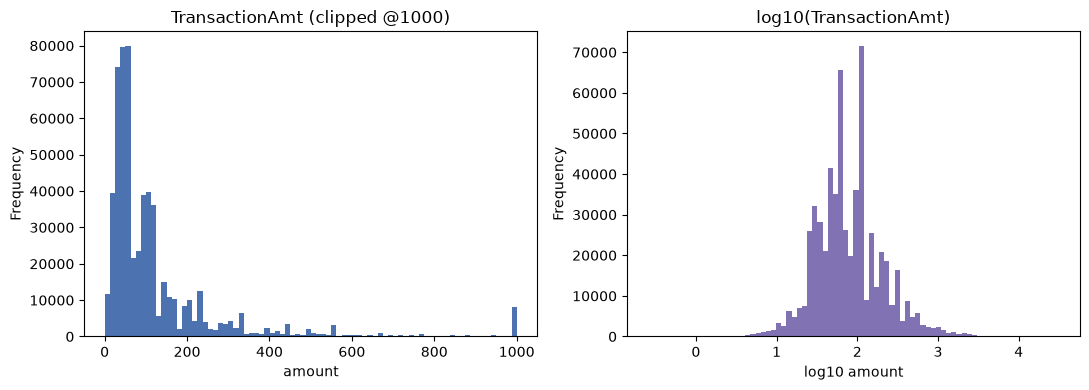

In [7]:
dt = df['TransactionDT']; span = (dt.max()-dt.min())/86400
print(f'TransactionDT range: {dt.min():,} .. {dt.max():,}  (~{span:.0f} days; it is a seconds offset, not a wall clock)')
print(df['TransactionAmt'].describe(percentiles=[.5,.9,.99]).to_string())
print(f"fraud median amt = {df.loc[df.isFraud==1,'TransactionAmt'].median():.2f}  |  "
      f"legit median amt = {df.loc[df.isFraud==0,'TransactionAmt'].median():.2f}")
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df['TransactionAmt'].clip(upper=1000).plot(kind='hist', bins=80, ax=ax[0], color='#4c72b0')
ax[0].set_title('TransactionAmt (clipped @1000)'); ax[0].set_xlabel('amount')
np.log10(df['TransactionAmt']).plot(kind='hist', bins=80, ax=ax[1], color='#8172b3')
ax[1].set_title('log10(TransactionAmt)'); ax[1].set_xlabel('log10 amount')
plt.tight_layout(); plt.savefig(config.FIGURES_DIR/'transaction_amt.png', dpi=110); plt.show()

`TransactionDT` spans **~182 days** of seconds offsets (not a real timestamp) — this is the ordering key for the split and the stream replay. `TransactionAmt` is heavily right-skewed (median ~69, max ~31,937). Notably fraud is **not** simply 'large amounts': the median fraud amount (75) is barely above legit (68.5). Amount alone is a weak separator — the signal is in the combinations.

## 6. Fraud rate over time

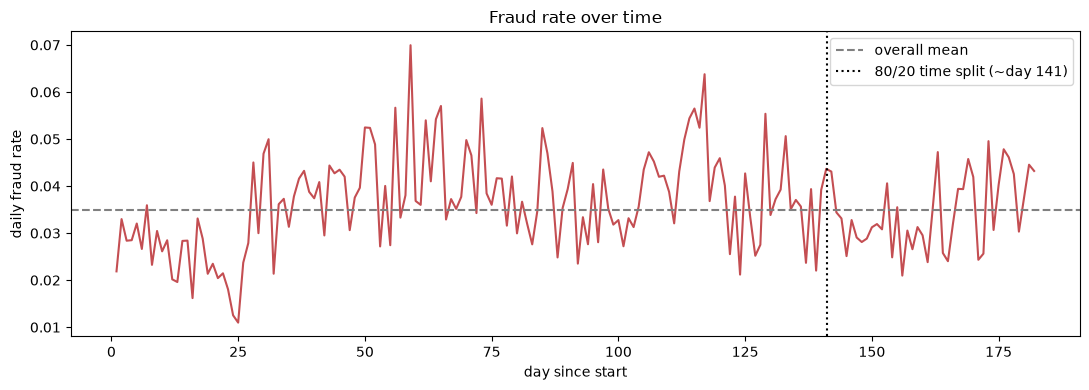

daily fraud rate: min=1.10%  max=6.99%  std=1.00%


In [8]:
day = (df['TransactionDT']//86400).astype(int)
by_day = df.assign(day=day).groupby('day').agg(n=('isFraud','size'), fraud_rate=('isFraud','mean'))
cut_day = df['TransactionDT'].quantile(0.8, interpolation='lower')/86400
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(by_day.index, by_day['fraud_rate'], color='#c44e52')
ax.axhline(df['isFraud'].mean(), ls='--', color='grey', label='overall mean')
ax.axvline(cut_day, ls=':', color='black', label=f'80/20 time split (~day {cut_day:.0f})')
ax.set_xlabel('day since start'); ax.set_ylabel('daily fraud rate')
ax.set_title('Fraud rate over time'); ax.legend()
plt.tight_layout(); plt.savefig(config.FIGURES_DIR/'fraud_over_time.png', dpi=110); plt.show()
print(f"daily fraud rate: min={by_day['fraud_rate'].min():.2%}  max={by_day['fraud_rate'].max():.2%}  std={by_day['fraud_rate'].std():.2%}")

The daily fraud rate is **non-stationary**, swinging from ~1.1% to ~7.0% (std ~1pp) across the 182 days. This is the core justification for the whole project: a model trained on an early window will see a shifted fraud rate later — which is what drift detection and retraining (M5) exist to catch. The dotted line marks where the 80/20 time split falls (~day 141).

## Summary of findings

- **Class imbalance:** fraud = **3.50%** (20,663 / 590,540), ≈1:27. Headline metric must be PR-AUC / precision@k, never accuracy.
- **Missingness is heavy and *structured*:** `id_*` ~85%, `D` ~58%, `M` ~50%, `email` ~46%, `V` ~43%; `C`/`card` ~complete. Missing-ness itself carries signal — handle NaNs deliberately, don't blanket-drop.
- **Identity presence is a top signal:** only **24.4%** of rows have identity data, but those are **3.7× more likely fraud** (7.8% vs 2.1%). The `has_identity` flag captures this.
- **Device matters:** mobile **10.2%** fraud > desktop **6.5%** > no-device **2.1%**.
- **Amount is a weak lone signal:** heavy right-skew, but fraud vs legit medians are close (75 vs 68.5). Fraud ≠ big tickets.
- **Non-stationarity:** daily fraud rate ranges **1.1%–7.0%** over the **~182-day** window — motivates drift-triggered retraining.

**Methodology implications carried into modeling:** time-based 80/20 split (~day 141 boundary) — never random; keep `has_identity`; exclude raw `TransactionDT`/`TransactionID` from features; class-weight for imbalance; report PR-AUC + precision@k.